# **Assignement 1**


## Task 1 
- ### *Train a fully connected neural network and convolutional neural network for binary classification.*

### **Create Dataset and DataLoader objects for provided training and validation data**

In [1]:
from tqdm.notebook import tqdm
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("We are using {}".format(device))

We are using cuda


In [2]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Resize, ToTensor, Normalize, Compose
from torch.utils.data import DataLoader
root_dir = 'chest_xray_64'

target_size = (64, 64) # Resize images to 64x64
transforms = Compose([Resize(target_size), # Resizes image
                      ToTensor(),           # Converts to Tensor, scales to [0, 1] float (from [0, 255] int)
                      Normalize(mean=(0.5, 0.5, 0.5,), std=(0.5, 0.5, 0.5)), # scales to [-1.0, 1.0]
                    ])

train_dataset_ = ImageFolder('chest_xray_64/train', transform=transforms)
val_dataset_ = ImageFolder('chest_xray_64/val', transform=transforms)

In [3]:
class RAMDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset):
        data = []
        for sample in tqdm(dataset):
            data.append(sample)
        self.n = len(dataset)
        self.data = data
        
    def __getitem__(self, ind):
        return self.data[ind]

    def set_transform(self, transform):
        self.transform = transform
    
    def __len__(self):
        return self.n

In [4]:
batch_size = 32

train_dataset = RAMDatasetWrapper(train_dataset_)
val_dataset = RAMDatasetWrapper(val_dataset_)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

  0%|          | 0/5216 [00:00<?, ?it/s]

  0%|          | 0/624 [00:00<?, ?it/s]

### **Load an Image from each class: Normal and Pneumonia**

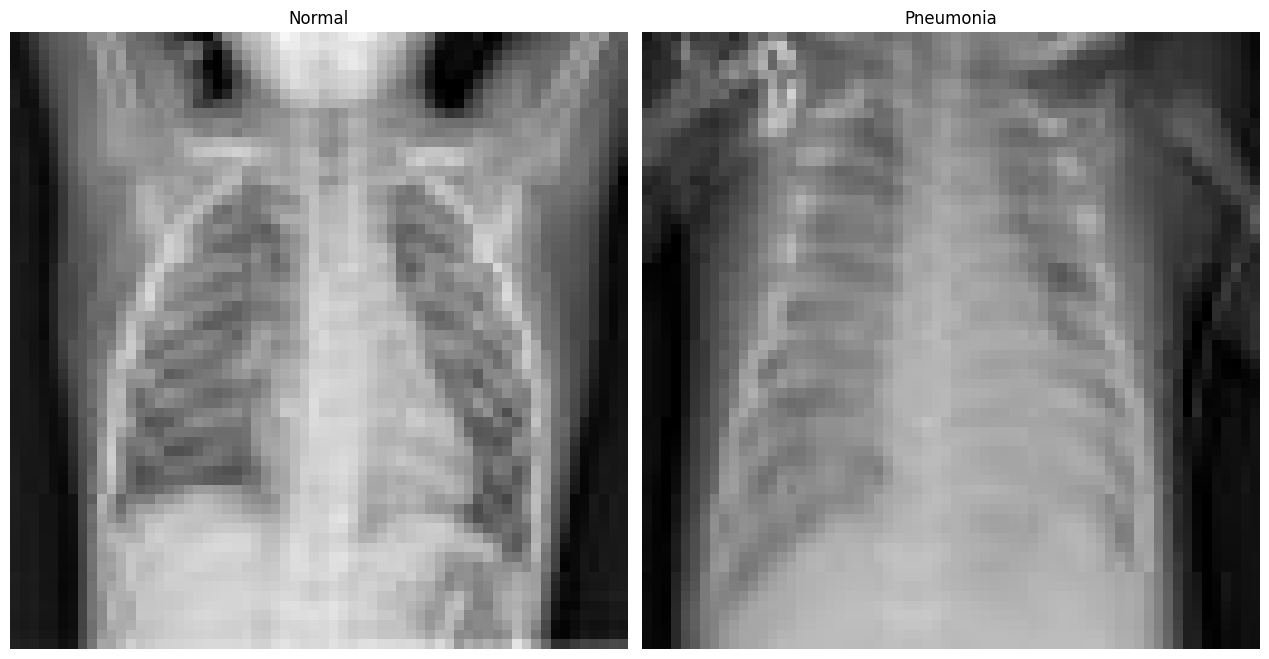

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

label_dict = {0: 'Normal', 1: 'Pneumonia'}
samples_per_class = {}

# Loop through dataset to collect one image per class
for img, label in train_dataset:
    if label not in samples_per_class:
        samples_per_class[label] = img
    if len(samples_per_class) == len(label_dict):
        break  # We have one image from each class

fig, axes = plt.subplots(1, len(samples_per_class), figsize=(12.8, 9.6))
for i, (label, img) in enumerate(samples_per_class.items()):
    img = img.mul(0.5).add(0.5)  
    img_np = img.permute(1, 2, 0).cpu().numpy()
    axes[i].imshow(img_np)
    axes[i].set_title(label_dict[label])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### **MLP model implementation**


In [6]:
import torch.nn as nn

class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel,self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(3 * 64 * 64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, input):
        input = input.view(input.size(0), -1)
        return self.layers(input)

### **Convolutional model implementation**

In [7]:
class ConvModel(nn.Module):
    def __init__(self):
        super(ConvModel, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # Layer 1 | Input: 3 x 64 x 64
            nn.Conv2d(3, 32, kernel_size=3, stride=1), # Output: 32 x 62 x 62 
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True), # Output: 32 x 31 x 31
            nn.ReLU(),
            
            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1), # Output: 64 x 29 x 29
            nn.MaxPool2d(kernel_size=3, stride=2), # Output: 64 x 14 x 14
            nn.ReLU(),
            
            # Layer 3
            nn.Conv2d(64, 64, kernel_size=3, stride=1), # Output: 64 x 12 x 12
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 64 x 6 x 6
            nn.ReLU(),
            
            # Layer 4
            nn.Conv2d(64, 128, kernel_size=2, stride=1), # Output: 128 x 5 x 5
            nn.ReLU(),
            
            # Layer 5
            nn.Conv2d(128, 256, kernel_size=3, stride=1), # Output: 256 x 3 x 3
            nn.ReLU(),
            
            #  Layer 6
            nn.Conv2d(256, 256, kernel_size=3, stride=1), # Output: 256 x 1 x 1
            nn.ReLU(),
            
            # Output layer
            nn.Conv2d(256, 2, kernel_size=1, stride=1) # Output: 2 x 1 x 1
        )
        
        
    def forward(self, input):
        output = self.conv_layers(input)
        # Flatten the output to 2 x 1
        output = output.view(input.size(0), -1)
        return output

### **Design the training code**

In [8]:
import numpy as np
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0
    # Iterate mini batches over training dataset
    for images, labels in tqdm(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        # Run predictions
        output = model(images)
        # Set gradients to zero
        optimizer.zero_grad()
        # Compute loss
        loss = loss_fn(output, labels)
        # Backpropagate (compute gradients)
        loss.backward()
        # Make an optimization step (update parameters)
        optimizer.step()
        # Log metrics
        losses.append(loss.item())
        predicted_labels = output.argmax(dim=1)
        correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = 100.0 * correct_predictions / len(train_dataloader.dataset)
    # Return loss values for each iteration and accuracy
    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy

In [9]:
def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Run predictions
            output = model(images)
            # Compute loss
            loss = loss_fn(output, labels)
            # Save metrics
            predicted_labels = output.argmax(dim=1)
            correct_predictions += (predicted_labels == labels).sum().item()
            losses.append(loss.item())
    mean_loss = np.array(losses).mean()
    accuracy = 100.0 * correct_predictions / len(dataloader.dataset)
    # Return mean loss and accuracy
    return mean_loss, accuracy

In [10]:
def train(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    return train_losses, val_losses, train_accuracies, val_accuracies

### **MLP model training**

In [11]:
model_mlp = MLPModel()
model_mlp = model_mlp.to(device)

# Train the MLP model
learning_rate = 0.001
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
n_epochs = 30
train_losses_mlp, val_losses_mlp, train_accuracies_mlp, val_accuracies_mlp = train(
    model_mlp, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.2007, train_accuracy: 92.1971, val_loss: 0.7416, val_accuracy: 76.7628


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1330, train_accuracy: 94.9770, val_loss: 0.7161, val_accuracy: 79.0064


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss: 0.0176, train_accuracy: 99.3290, val_loss: 2.0393, val_accuracy: 78.2051


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 29/30: train_loss: 0.0177, train_accuracy: 99.4440, val_loss: 1.9430, val_accuracy: 75.3205


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 30/30: train_loss: 0.0213, train_accuracy: 99.2715, val_loss: 2.3954, val_accuracy: 76.7628


In [12]:
def plot(train_losses, val_losses, train_accuracies, val_accuracies, title):
    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('{}: Train/val loss'.format(title));

    plt.figure()
    plt.plot(np.arange(len(train_accuracies)), train_accuracies)
    plt.plot(np.arange(len(val_accuracies)), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('{}: Train/val accuracy'.format(title))

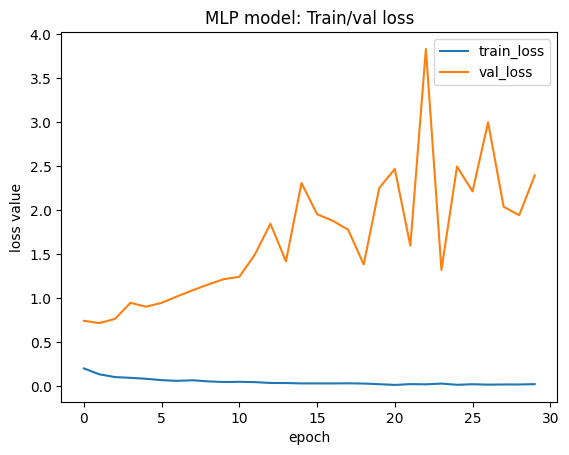

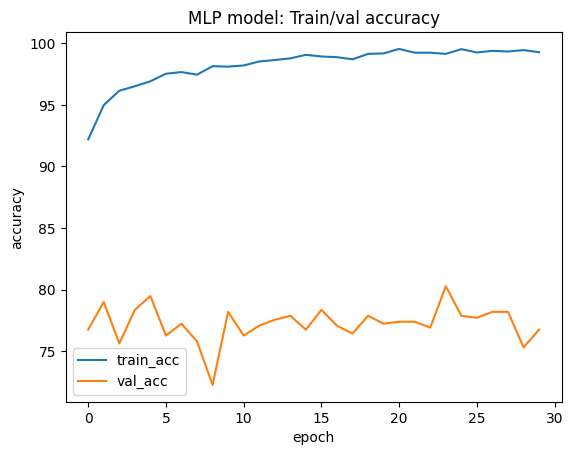

In [13]:
plot(train_losses_mlp, val_losses_mlp, train_accuracies_mlp, val_accuracies_mlp, title='MLP model')

### **Convolutional model training**

In [14]:
model_conv = ConvModel()
model_conv = model_conv.to(device)

# Train the Convolutional model
learning_rate = 0.001
optimizer = torch.optim.Adam(model_conv.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
n_epochs = 30
train_losses_conv, val_losses_conv, train_accuracies_conv, val_accuracies_conv = train(
    model_conv, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.2761, train_accuracy: 87.9793, val_loss: 0.7612, val_accuracy: 74.1987


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1198, train_accuracy: 95.4755, val_loss: 0.8434, val_accuracy: 71.9551


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss: 0.0012, train_accuracy: 99.9808, val_loss: 2.1702, val_accuracy: 78.3654


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 29/30: train_loss: 0.0116, train_accuracy: 99.5590, val_loss: 1.6531, val_accuracy: 76.2821


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 30/30: train_loss: 0.0170, train_accuracy: 99.4248, val_loss: 2.7571, val_accuracy: 73.2372


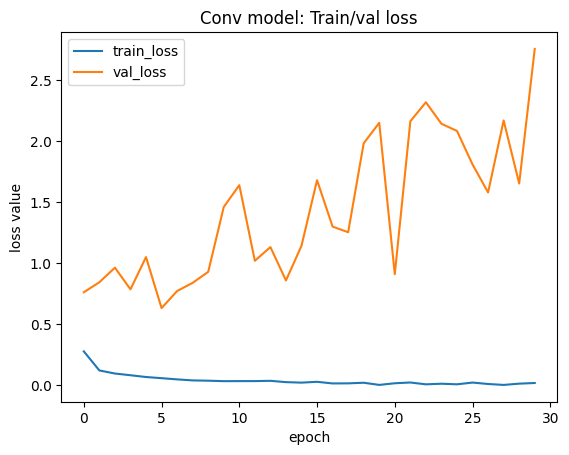

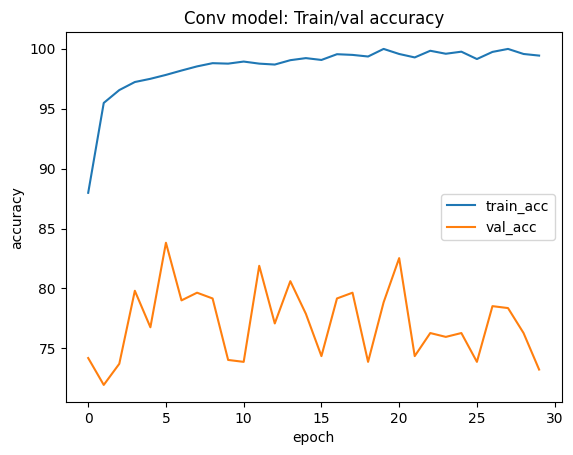

In [15]:
plot(train_losses_conv, val_losses_conv, train_accuracies_conv, val_accuracies_conv, title='Conv model')

## Task 2 
- ### *Add Regularization to your convolutional (CNN) model*

### **1st Regularization: Early Stopping**

In [16]:
from copy import deepcopy

def train_early_stopping(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    ### EARLY STOPPING INITIALIZATION
    best_val_accuracy = 0.
    best_model = None
    patience = 10 # if no improvement after 10 epochs, stop training
    counter = 0
    ###

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    
        ### EARLY STOPPING CODE
        if val_accuracy > best_val_accuracy: # If validation loss improved, save the model and reset the counter
            best_val_accuracy = val_accuracy
            best_model = deepcopy(model)
            counter = 0
        else: # If validation loss not improved, increase the counter
            counter += 1
        if counter == patience: # If no improvement for some number of epochs, stop training
            print('No improvement for {} epochs; training stopped.'.format(patience))
            break
    # Copy best model parameters to model
    for param1, param2 in zip(model.parameters(), best_model.parameters()):
        param1.data = param2.data
    ###
    return train_losses, val_losses, train_accuracies, val_accuracies

In [17]:
model_conv = ConvModel()
model_conv = model_conv.to(device)

# Train the Convolutional model with early stopping
learning_rate = 0.001
optimizer = torch.optim.Adam(model_conv.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
n_epochs = 30
train_losses_es, val_losses_es, train_accuracies_es, val_accuracies_es = train_early_stopping(
    model_conv, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.3675, train_accuracy: 83.1480, val_loss: 0.5896, val_accuracy: 74.8397


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.1683, train_accuracy: 93.0598, val_loss: 0.4810, val_accuracy: 79.6474


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 17/30: train_loss: 0.0234, train_accuracy: 99.0798, val_loss: 1.3563, val_accuracy: 76.4423


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 18/30: train_loss: 0.0186, train_accuracy: 99.2906, val_loss: 1.2673, val_accuracy: 78.3654


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 19/30: train_loss: 0.0111, train_accuracy: 99.6357, val_loss: 1.8657, val_accuracy: 75.3205
No improvement for 10 epochs; training stopped.


### **2nd Regularization: L2 Regularization / weight decay**

In [18]:
model_conv = ConvModel()
model_conv = model_conv.to(device)

# Train the Convolutional model with early stopping
learning_rate = 0.001
alpha = 0.0075 # L2 regularization
optimizer = torch.optim.Adam(model_conv.parameters(), lr=learning_rate, weight_decay=alpha)
loss_fn = nn.CrossEntropyLoss()
n_epochs = 30
train_losses_wd, val_losses_wd, train_accuracies_wd, val_accuracies_wd = train(
    model_conv, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/30: train_loss: 0.3779, train_accuracy: 81.3459, val_loss: 0.4050, val_accuracy: 84.6154


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/30: train_loss: 0.2183, train_accuracy: 91.0468, val_loss: 0.3176, val_accuracy: 87.0192


  0%|          | 0/163 [00:00<?, ?it/s]

...

Epoch 28/30: train_loss: 0.0602, train_accuracy: 97.8719, val_loss: 0.5799, val_accuracy: 79.0064


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 29/30: train_loss: 0.0628, train_accuracy: 97.6610, val_loss: 0.7073, val_accuracy: 75.6410


  0%|          | 0/163 [00:00<?, ?it/s]

Epoch 30/30: train_loss: 0.0594, train_accuracy: 97.9486, val_loss: 0.5709, val_accuracy: 78.8462


In [19]:
val_loss_mlp, val_accuracy_mlp = val_losses_mlp[-1], val_accuracies_mlp[-1]
print('MLP model. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_mlp, val_accuracy_mlp))
val_loss_conv, val_accuracy_conv = val_losses_conv[-1], val_accuracies_conv[-1]
print('Convolutional model. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_conv, val_accuracy_conv))
val_loss_es, val_accuracy_es = val_losses_es[-1], val_accuracies_es[-1]
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_es, val_accuracy_es))
val_loss_wd, val_accuracy_wd = val_losses_wd[-1], val_accuracies_wd[-1]
print('L2 regularization. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_wd, val_accuracy_wd))

MLP model. Validation loss: 2.3954, validation accuracy: 76.7628
Convolutional model. Validation loss: 2.7571, validation accuracy: 73.2372
Early stopping. Validation loss: 1.8657, validation accuracy: 75.3205
L2 regularization. Validation loss: 0.5709, validation accuracy: 78.8462


- **MLP model** Validation accuracy: 76.7628

- **Convolutional model** Validation accuracy: 73.2372

- **Early stopping** Validation accuracy: 75.3205

- **L2 regularization** Validation accuracy: 78.8462

Among the four trained models, the convolutional model with L2 regularization achieved the highest validation accuracy (78.85%), outperforming the MLP (76.76%), the base convolutional model (73.24%), and the convolutional model with early stopping (75.32%). Its success can be attributed to the combination of convolutional layers, which are well-suited for image data, and L2 regularization, which helped reduce overfitting by penalizing large weights. The base convolutional model likely overfit due to a lack of regularization, while early stopping may have halted training prematurely, limiting performance. Although the MLP performed surprisingly well given the image size, it lacks the spatial feature extraction capabilities of Convolutional NNs.